**Code to generate usage rate**

In [13]:
import pandas as pd

start_year= 2025
end_year=start_year+1
sites_csv   = f"trackercommondata_{start_year}_{end_year}_only_educational.csv"
info_csv    = "tracker_info.csv"
out_csv     = f"category_usage_{start_year}_{end_year}.csv"

df_sites = pd.read_csv(sites_csv, dtype=str)
df_info  = pd.read_csv(info_csv, dtype=str)

df_sites['Trackers'] = df_sites['Trackers'].fillna('').astype(str)
df_info['Tracker']   = df_info['Tracker'].fillna('').astype(str).str.strip()
df_info['Category']  = df_info['Category'].fillna('Unknown').astype(str).str.strip()

tracker_to_cat = {t.lower(): c for t, c in zip(df_info['Tracker'], df_info['Category']) if t}

total_websites = len(df_sites)

category_site_count = {}

for _, row in df_sites.iterrows():
    trackers_raw = [t.strip() for t in row['Trackers'].split(';') if t.strip()]
    categories_used = set()
    for t in trackers_raw:
        cat = tracker_to_cat.get(t.lower(), "Unknown")
        categories_used.add(cat)
    for cat in categories_used:
        category_site_count[cat] = category_site_count.get(cat, 0) + 1

res = (
    pd.DataFrame([
        {"Category": cat,
         "websites_using_category": cnt,
         "total_websites": total_websites,
         "usage_rate": cnt / total_websites if total_websites else 0.0}
        for cat, cnt in category_site_count.items()
    ])
    .sort_values("usage_rate", ascending=False)
    .reset_index(drop=True)
)

print(f"Category usage rates for {start_year}-{end_year} (usage_rate = websites_using_category / total_websites):")
for _, r in res.iterrows():
    print(f"{r['Category']}: {r['websites_using_category']}/{r['total_websites']} = {r['usage_rate']:.4f}")

res.to_csv(out_csv, index=False)
print(f"\nSaved to: {out_csv}")


Category usage rates for 2025-2026 (usage_rate = websites_using_category / total_websites):
Advertising: 10861/21289 = 0.5102
Hosting: 4799/21289 = 0.2254
Site Analytics: 2736/21289 = 0.1285
Audio/Video Player: 1836/21289 = 0.0862
CDN: 1775/21289 = 0.0834
Social Media: 1215/21289 = 0.0571
Customer Interaction: 888/21289 = 0.0417
Misc: 826/21289 = 0.0388
Consent Management: 511/21289 = 0.0240
Utilities: 510/21289 = 0.0240
Essential: 108/21289 = 0.0051
Unknown: 37/21289 = 0.0017
Extensions: 1/21289 = 0.0000

Saved to: category_usage_2025_2026.csv


**Code to merge csv files**

In [14]:
import pandas as pd
from pathlib import Path



out_merged = "category_usage_2013_2026_merged.csv"

frames = []
for start_year in range(2013, 2026):
    end_year = start_year + 1
    fname = f"category_usage_{start_year}_{end_year}.csv"
    path = Path(fname)
    if not path.exists():
        print(f"[skip] Missing file: {fname}")
        continue


    df = pd.read_csv(path)
    df.insert(0, "Year", f"{start_year}-{end_year}")
    frames.append(df)
    print(f"[ok] Added {fname} with {len(df)} rows")

if frames:
    merged = pd.concat(frames, ignore_index=True)
    merged.to_csv(out_merged, index=False)
    print(f"\nSaved merged file with {len(merged)} rows to: {out_merged}")
else:
    print("No files were found to merge.")


[ok] Added category_usage_2013_2014.csv with 10 rows
[ok] Added category_usage_2014_2015.csv with 12 rows
[ok] Added category_usage_2015_2016.csv with 11 rows
[ok] Added category_usage_2016_2017.csv with 12 rows
[ok] Added category_usage_2017_2018.csv with 13 rows
[ok] Added category_usage_2018_2019.csv with 12 rows
[ok] Added category_usage_2019_2020.csv with 11 rows
[ok] Added category_usage_2020_2021.csv with 12 rows
[ok] Added category_usage_2021_2022.csv with 13 rows
[ok] Added category_usage_2022_2023.csv with 13 rows
[ok] Added category_usage_2023_2024.csv with 13 rows
[ok] Added category_usage_2024_2025.csv with 13 rows
[ok] Added category_usage_2025_2026.csv with 13 rows

Saved merged file with 158 rows to: category_usage_2013_2026_merged.csv


**Code to make line plot**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re


merged_csv = "category_usage_2013_2026_merged.csv"
out_png    = "category_usage_trends_selected.png"

target_categories = [
    "Advertising",
    "Audio/Video Player",
    "CDN",
    "Customer Interaction",
    "Hosting",
    "Site Analytics",
    "Social Media",
    "Utilities",
]

df = pd.read_csv(merged_csv, dtype={"Year": str, "Category": str})


df["Category_norm"]  = df["Category"].astype(str).str.strip()
df["Category_lower"] = df["Category_norm"].str.lower()
targets_lower = {c.lower() for c in target_categories}


df_sel = df[df["Category_lower"].isin(targets_lower)].copy()

def start_year(y):
    m = re.match(r"^\s*(\d{4})\s*-\s*(\d{4})\s*$", str(y))
    return int(m.group(1)) if m else 0

df_sel["YearStart"] = df_sel["Year"].apply(start_year)


pivot = (
    df_sel.pivot_table(index=["YearStart", "Year"], columns="Category_norm",
                       values="usage_rate", aggfunc="first")
    .sort_index(level=0)
).reset_index()


years_start = pivot["YearStart"].tolist()


available_cols = [c for c in target_categories if c in pivot.columns]
if not available_cols:
    raise ValueError("None of the requested categories were found in the merged CSV.")


plt.figure(figsize=(14, 7))

for cat in available_cols:
    y_vals = pivot[cat].astype(float)
    plt.plot(years_start, y_vals, marker="o", label=cat)

plt.ylim(0, 0.6)
plt.xlabel("Year", fontsize=17)
plt.ylabel("Usage rate", fontsize=17)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(years_start, [str(y) for y in years_start], ha="right", fontsize=17)  # <-- shows "2013" not "2013-2014"
plt.legend(loc="best", fontsize=17)
plt.yticks(fontsize=17)
plt.tight_layout()
plt.savefig(out_png, dpi=400)
plt.close()

print(f"Saved line chart to: {out_png}")


Saved line chart to: category_usage_trends_selected.png


**Code to make grouped bar**

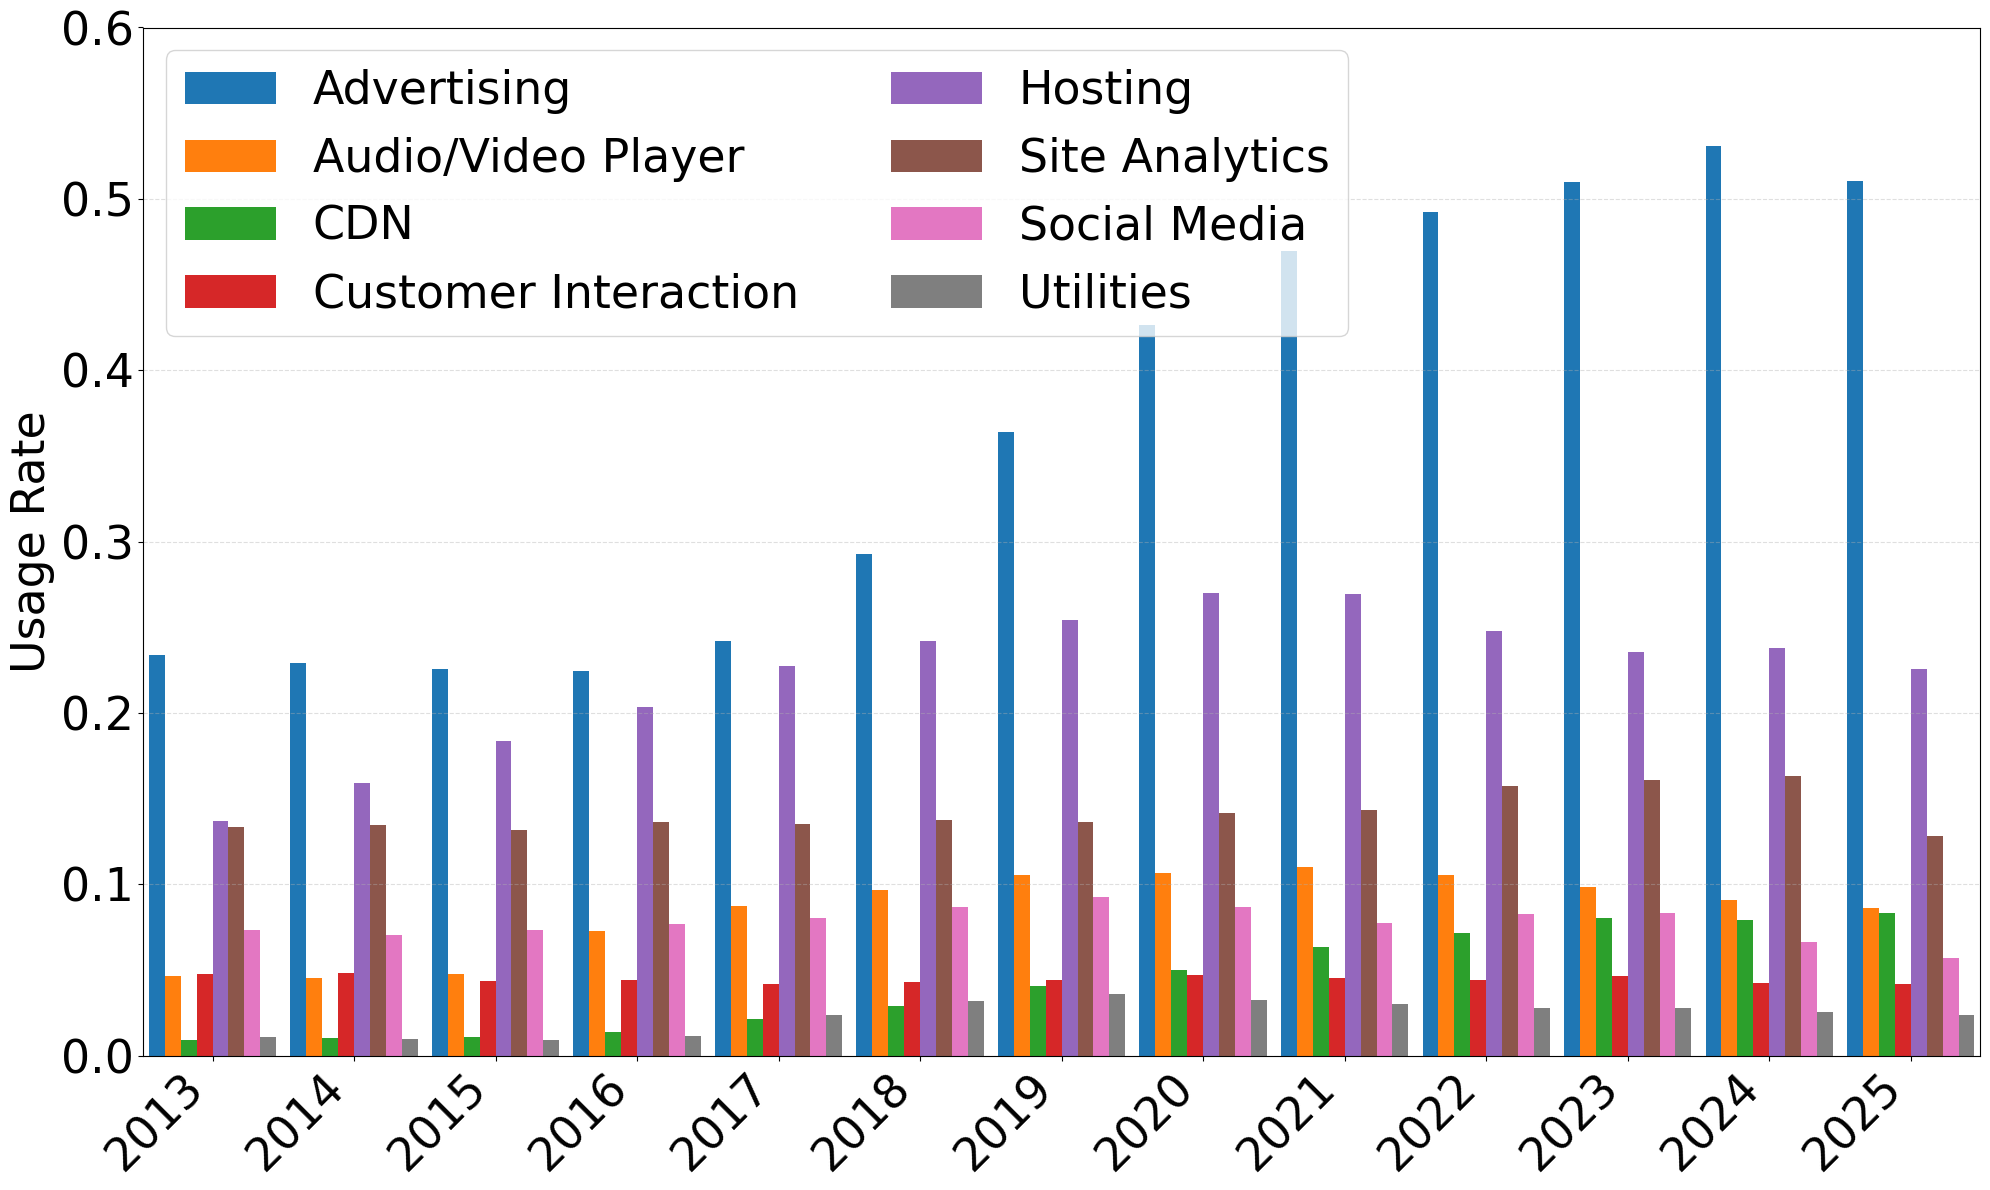

Saved grouped bar chart to: category_usage_trends_selected_grouped_bar.png


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

merged_csv = "category_usage_2013_2026_merged.csv"
out_png    = "category_usage_trends_selected_grouped_bar.png"

target_categories = [
    "Advertising",
    "Audio/Video Player",
    "CDN",
    "Customer Interaction",
    "Hosting",

    "Site Analytics",
    "Social Media",
    "Utilities",
]

df = pd.read_csv(merged_csv, dtype={"Year": str, "Category": str})

df["Category_norm"]  = df["Category"].astype(str).str.strip()
df["Category_lower"] = df["Category_norm"].str.lower()
targets_lower = [c.lower() for c in target_categories]
df_sel = df[df["Category_lower"].isin(targets_lower)].copy()

def start_year(y):
    m = re.match(r"^\s*(\d{4})\s*-\s*(\d{4})\s*$", str(y))
    return int(m.group(1)) if m else 0

df_sel["YearStart"] = df_sel["Year"].apply(start_year)


wide = (
    df_sel.pivot_table(index="YearStart", columns="Category_norm",
                       values="usage_rate", aggfunc="first")
    .sort_index()
)


available_cols = [c for c in target_categories if c in wide.columns]
if not available_cols:
    raise ValueError("None of the requested categories were found in the merged CSV.")
wide = wide[available_cols]


years = wide.index.to_numpy()
x = np.arange(len(years))                  # group centers
k = len(available_cols)                    # bars per group
group_width = 0.90                        # total width allocated to each group
bar_w = group_width / k                    # width of each bar
offsets = (np.arange(k) - (k - 1) / 2.0) * bar_w

plt.figure(figsize=(20, 12))

for j, cat in enumerate(available_cols):
    y_vals = wide[cat].astype(float).to_numpy()
    plt.bar(x + offsets[j], y_vals, width=bar_w, label=cat)

plt.ylim(0, 0.6)
plt.ylabel("Usage Rate", fontsize=33)

plt.xticks(x, years.astype(str), fontsize=33, rotation=45, ha="right")

plt.yticks(fontsize=33)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(loc="best", fontsize=33, ncol=2)

left_edge  = (x[0]  + offsets.min()) - bar_w/2.0
right_edge = (x[-1] + offsets.max()) + bar_w/2.0
pad = bar_w * 0.35
plt.xlim(left_edge - pad, right_edge + pad)

plt.tight_layout()
plt.savefig(out_png, dpi=600)

plt.show()
print(f"Saved grouped bar chart to: {out_png}")
